In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path
from matplotlib import pyplot as plt

DATA_PATH = Path("./data")

transport_lines = gpd.read_file(
    DATA_PATH / "public_transport_lines.geojson"
)

transport_stops = gpd.read_file(
    DATA_PATH / "public_transport_stops.geojson"
)

# check shape
print("Transport Lines")
print(transport_lines.shape)
print("\nTransport Stops")
print(transport_stops.shape)

Transport Lines
(10982, 6)

Transport Stops
(31170, 4)


In [2]:
print("===========Transport Lines============")
print(transport_lines.head())
print("===========Transport stops==============")
print(transport_stops.head())

print(transport_lines.columns.tolist())
print(transport_stops.columns.tolist())

===========Transport Lines============
           SHAPE_ID        HEADSIGN SHORT_NAME  \
0  1-ABY-mjp-10.1.H          Albury    Seymour   
1  1-ABY-mjp-10.2.R  Southern Cross    Seymour   
2  1-ABY-mjp-11.1.H          Albury    Seymour   
3  1-ABY-mjp-11.2.R  Southern Cross    Seymour   
4  1-ABY-mjp-12.1.H          Albury    Seymour   

                        LONG_NAME            MODE  \
0  Albury - Melbourne Via Seymour  REGIONAL TRAIN   
1  Albury - Melbourne Via Seymour  REGIONAL TRAIN   
2  Albury - Melbourne Via Seymour  REGIONAL TRAIN   
3  Albury - Melbourne Via Seymour  REGIONAL TRAIN   
4  Albury - Melbourne Via Seymour  REGIONAL TRAIN   

                                            geometry  
0  LINESTRING (144.95214 -37.81817, 144.95207 -37...  
1  LINESTRING (146.9246 -36.08427, 146.92383 -36....  
2  LINESTRING (144.95214 -37.81817, 144.95207 -37...  
3  LINESTRING (146.9246 -36.08427, 146.92383 -36....  
4  LINESTRING (144.95214 -37.81817, 144.95207 -37...  
===========

In [3]:
transport_lines.geometry.geom_type.value_counts()
transport_stops.geometry.geom_type.value_counts()
print(transport_lines.crs)
print(transport_stops.crs)

# Check missing 
transport_lines.isnull().sum()
transport_stops.isnull().sum()

EPSG:4326
EPSG:4326


STOP_ID      0
STOP_NAME    0
MODE         0
geometry     0
dtype: int64

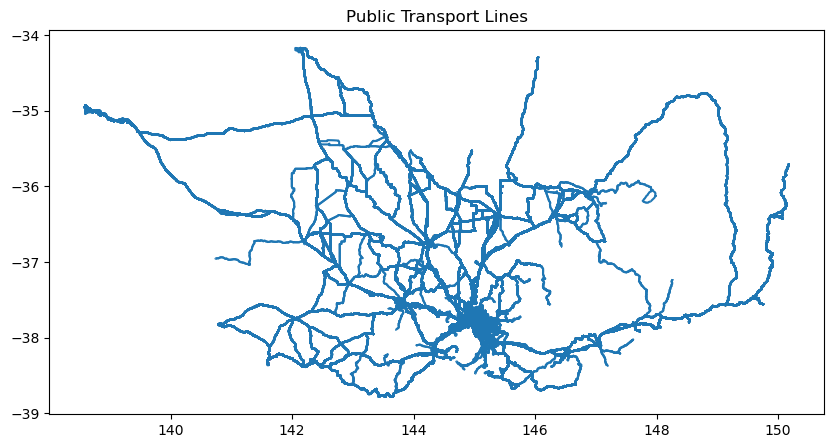

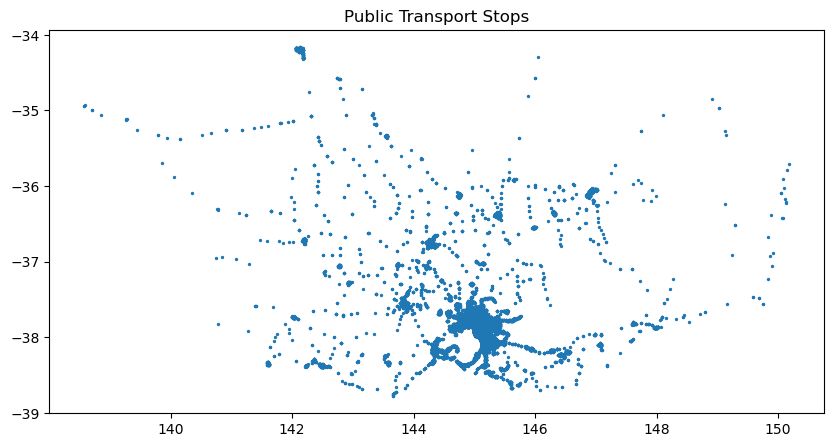

In [4]:
# Visualize
#transport lines
transport_lines.plot(
    figsize=(10,10)
)
plt.title(
    "Public Transport Lines"
)
plt.show()
# transport stop
transport_stops.plot(
    figsize=(10,10),
    markersize=2
)
plt.title(
    "Public Transport Stops"
)
plt.show()

# Cleaning 

In [5]:
# -- Cleaning transport lines

bus_lines = transport_lines[
    transport_lines["MODE"].isin(
        [
            "METRO BUS",
            "REGIONAL BUS"
        ]
    )
].copy()

bus_lines.head()


,SHAPE_ID,HEADSIGN,SHORT_NAME,LONG_NAME,MODE,geometry
4171,14-200-aus-1.2.H,Bulleen Terminus,200,Bulleen - City (Queen St),METRO BUS,"LINESTRING (144.96116 -37.81616, 144.96109 -37..."
4172,14-200-aus-1.3.R,Little Collins St,200,Bulleen - City (Queen St),METRO BUS,"LINESTRING (145.0998 -37.7699, 145.10028 -37.7..."
4173,14-207-aus-1.2.R,Little Collins St,207,Doncaster SC - City (Queen St),METRO BUS,"LINESTRING (145.12484 -37.78355, 145.12481 -37..."
4174,14-207-aus-1.3.H,Doncaster SC,207,Doncaster SC - City (Queen St),METRO BUS,"LINESTRING (144.96116 -37.81616, 144.96109 -37..."
4175,14-270-aus-1.2.R,Box Hill,270,Mitcham - Box Hill,METRO BUS,"LINESTRING (145.1919 -37.818, 145.19172 -37.81..."


In [6]:
#-- cleaning transport stop
bus_stops = transport_stops[
    transport_stops["MODE"].isin(
        [
            "METRO BUS",
            "REGIONAL BUS"
        ]
    )
].copy()

bus_stops.head()

,STOP_ID,STOP_NAME,MODE,geometry
54,13626,Lakeside Bvd/Princes Hwy,REGIONAL BUS,POINT (145.45671 -38.06235)
55,13763,High St/Main Rd,REGIONAL BUS,POINT (144.73661 -37.27812)
56,13764,High St/Main Rd,REGIONAL BUS,POINT (144.73681 -37.27805)
57,13765,Romsey Community Hub/Main St,REGIONAL BUS,POINT (144.74281 -37.35009)
58,13766,Romsey Community Hub/Main St,REGIONAL BUS,POINT (144.74304 -37.35012)


# EDA

In [7]:
# -- number of bus routes
bus_lines.groupby(
    "MODE"
).size()

MODE
METRO BUS       2654
REGIONAL BUS     479
dtype: int64

In [8]:
#-- number of bus stops
bus_stops.groupby(
    "MODE"
).size()

MODE
METRO BUS       22478
REGIONAL BUS     3282
dtype: int64

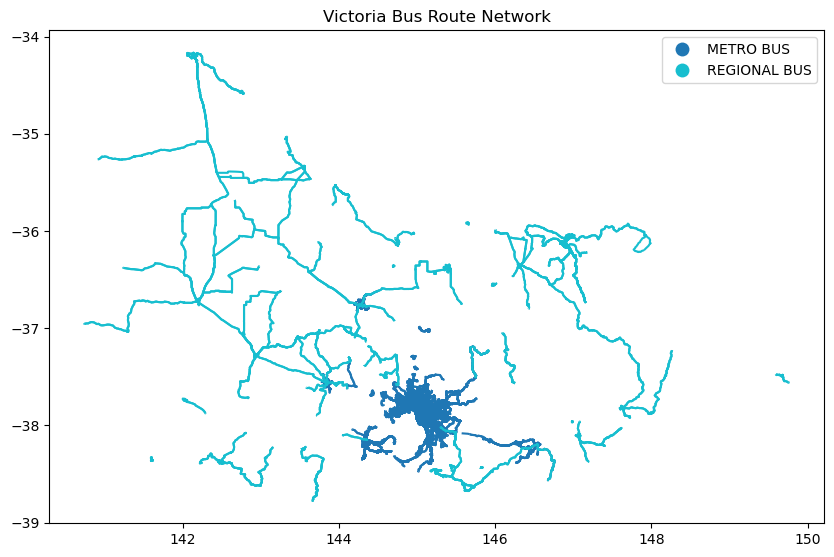

In [9]:
#--- Map bus routes
import matplotlib.pyplot as plt
fig, ax = plt.subplots(
    figsize=(10,10)
)

bus_lines.plot(
    ax=ax,
    column="MODE",
    legend=True
)
plt.title(
    "Victoria Bus Route Network"
)
plt.show()

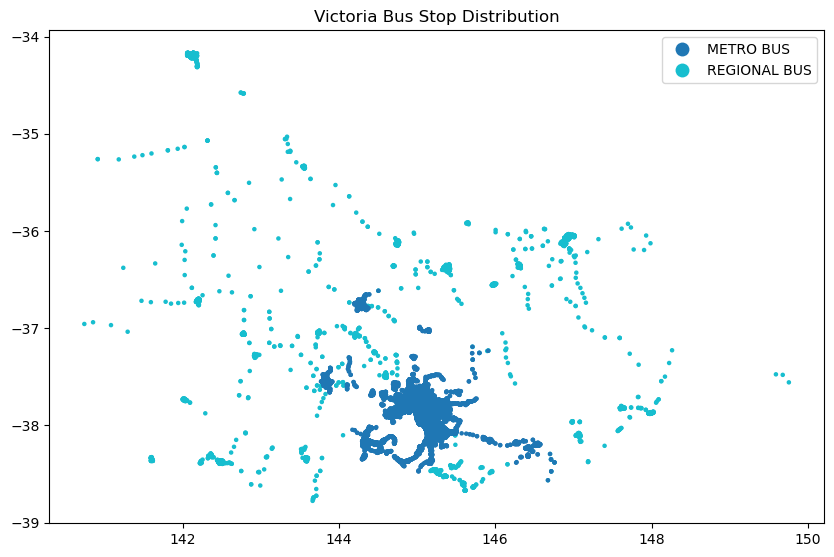

In [10]:
#-- Map bus stops
fig, ax = plt.subplots(
    figsize=(10,10)
)


bus_stops.plot(
    ax=ax,
    column="MODE",
    markersize=5,
    legend=True
)


plt.title(
    "Victoria Bus Stop Distribution"
)

plt.show()

# Save dataset

In [11]:
# 1. Ensure target directory exists
PROCESSED_DATA_PATH = Path("./processed_data")
PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

# 2. Map processed GeoDataFrames to export file names
geo_datasets = {
    "bus_lines": (bus_lines, "bus_lines.geojson"),
    "bus_stops": (bus_stops, "bus_stops.geojson")
}

# 3. Export to GeoJSON and print required metadata
for name, (gdf, filename) in geo_datasets.items():
    file_path = PROCESSED_DATA_PATH / filename
    
    # Save spatial dataframe using GeoJSON driver
    gdf.to_file(file_path, driver="GeoJSON")
    
    # Display inspection outputs
    print("=" * 60)
    print(f" GEODATASET: {name} (Saved to: {file_path})")
    print("=" * 60)
    print(gdf.columns.to_list())
    print("\n--- Head (3) ---")
    print(gdf.head(3))
    print("\n--- Info ---")
    gdf.info()
    print("\n" + "\n")

 GEODATASET: bus_lines (Saved to: processed_data\bus_lines.geojson)
['SHAPE_ID', 'HEADSIGN', 'SHORT_NAME', 'LONG_NAME', 'MODE', 'geometry']

--- Head (3) ---
              SHAPE_ID           HEADSIGN SHORT_NAME  \
4171  14-200-aus-1.2.H   Bulleen Terminus        200   
4172  14-200-aus-1.3.R  Little Collins St        200   
4173  14-207-aus-1.2.R  Little Collins St        207   

                           LONG_NAME       MODE  \
4171       Bulleen - City (Queen St)  METRO BUS   
4172       Bulleen - City (Queen St)  METRO BUS   
4173  Doncaster SC - City (Queen St)  METRO BUS   

                                               geometry  
4171  LINESTRING (144.96116 -37.81616, 144.96109 -37...  
4172  LINESTRING (145.0998 -37.7699, 145.10028 -37.7...  
4173  LINESTRING (145.12484 -37.78355, 145.12481 -37...  

--- Info ---
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 3133 entries, 4171 to 10955
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------